# 2026 World Cup Monte Carlo Simulation — Optimized Version

This notebook is a faster rewrite of the 48-team Monte Carlo simulator.

Main speed improvements:

1. **Caches all model probabilities before the simulation loop**
2. **Avoids pandas DataFrames inside the simulation loop**
3. **Uses pure Python dictionaries/lists for tournament simulation**
4. **Converts to pandas only at the end**

This should run much faster than the earlier version.


In [12]:
import pandas as pd
import numpy as np
from pathlib import Path
import pickle
import time
import matplotlib.pyplot as plt

pd.set_option("display.max_columns", 100)

DATA_DIR = Path.cwd() / "data"
MODEL_DIR = Path.cwd() / "models"
OUTPUT_DIR = Path.cwd() / "outputs"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

N_SIMULATIONS = 10000
RANDOM_SEED = 42

print("Current working directory:", Path.cwd())
print("Simulations:", N_SIMULATIONS)


Current working directory: c:\Users\conno\OneDrive\Documents\World Cup Analytics
Simulations: 10000


## 1. Load model and model outputs

In [13]:
MODEL_PATH = MODEL_DIR / "logistic_regression_match_model.pkl"
ELO_PATH = DATA_DIR / "elo_table.csv"
MODEL_READY_PATH = DATA_DIR / "model_ready_matches.csv"

if not MODEL_PATH.exists():
    raise FileNotFoundError(f"Missing model file: {MODEL_PATH}")

if not ELO_PATH.exists():
    raise FileNotFoundError(f"Missing Elo file: {ELO_PATH}")

if not MODEL_READY_PATH.exists():
    raise FileNotFoundError(f"Missing model-ready data: {MODEL_READY_PATH}")

with open(MODEL_PATH, "rb") as f:
    match_model = pickle.load(f)

elo_table = pd.read_csv(ELO_PATH)
model_ready = pd.read_csv(MODEL_READY_PATH)
model_ready["date"] = pd.to_datetime(model_ready["date"], errors="coerce")

print("Model classes:", match_model.classes_)
print("Elo rows:", len(elo_table))
print("Model-ready rows:", len(model_ready))


Model classes: ['away_win' 'draw' 'home_win']
Elo rows: 336
Model-ready rows: 49373


## 2. Define 2026 World Cup groups

In [14]:
team_name_map = {
    "Mexico": "Mexico",
    "South Africa": "South Africa",
    "Korea Republic": "South Korea",
    "Czechia": "Czech Republic",
    "Canada": "Canada",
    "Bosnia and Herzegovina": "Bosnia and Herzegovina",
    "Qatar": "Qatar",
    "Switzerland": "Switzerland",
    "Brazil": "Brazil",
    "Haiti": "Haiti",
    "Morocco": "Morocco",
    "Scotland": "Scotland",
    "United States": "United States",
    "Paraguay": "Paraguay",
    "Australia": "Australia",
    "Türkiye": "Turkey",
    "Germany": "Germany",
    "Curaçao": "Curacao",
    "Côte d'Ivoire": "Ivory Coast",
    "Ecuador": "Ecuador",
    "Netherlands": "Netherlands",
    "Japan": "Japan",
    "Sweden": "Sweden",
    "Tunisia": "Tunisia",
    "Belgium": "Belgium",
    "Egypt": "Egypt",
    "IR Iran": "Iran",
    "New Zealand": "New Zealand",
    "Spain": "Spain",
    "Cabo Verde": "Cape Verde",
    "Saudi Arabia": "Saudi Arabia",
    "Uruguay": "Uruguay",
    "France": "France",
    "Senegal": "Senegal",
    "Iraq": "Iraq",
    "Norway": "Norway",
    "Argentina": "Argentina",
    "Algeria": "Algeria",
    "Austria": "Austria",
    "Jordan": "Jordan",
    "Portugal": "Portugal",
    "Congo DR": "DR Congo",
    "Uzbekistan": "Uzbekistan",
    "Colombia": "Colombia",
    "England": "England",
    "Croatia": "Croatia",
    "Ghana": "Ghana",
    "Panama": "Panama",
}

groups_official = {
    "Group A": ["Mexico", "South Africa", "Korea Republic", "Czechia"],
    "Group B": ["Canada", "Bosnia and Herzegovina", "Qatar", "Switzerland"],
    "Group C": ["Brazil", "Haiti", "Morocco", "Scotland"],
    "Group D": ["United States", "Paraguay", "Australia", "Türkiye"],
    "Group E": ["Germany", "Curaçao", "Côte d'Ivoire", "Ecuador"],
    "Group F": ["Netherlands", "Japan", "Sweden", "Tunisia"],
    "Group G": ["Belgium", "Egypt", "IR Iran", "New Zealand"],
    "Group H": ["Spain", "Cabo Verde", "Saudi Arabia", "Uruguay"],
    "Group I": ["France", "Senegal", "Iraq", "Norway"],
    "Group J": ["Argentina", "Algeria", "Austria", "Jordan"],
    "Group K": ["Portugal", "Congo DR", "Uzbekistan", "Colombia"],
    "Group L": ["England", "Croatia", "Ghana", "Panama"],
}

groups_model = {group: [team_name_map[t] for t in teams] for group, teams in groups_official.items()}

model_to_display = {v: k for k, v in team_name_map.items()}
for official, model_name in team_name_map.items():
    model_to_display.setdefault(model_name, official)

all_teams = [team for teams in groups_model.values() for team in teams]

print("Teams:", len(all_teams))
print("Unique teams:", len(set(all_teams)))


Teams: 48
Unique teams: 48


## 3. Build team-strength lookups

In [15]:
elo_lookup = dict(zip(elo_table["team"], elo_table["elo"]))

missing_from_elo = [team for team in all_teams if team not in elo_lookup]
if missing_from_elo:
    print("WARNING: These teams were not found in the Elo table and will default to 1500:")
    for team in missing_from_elo:
        print("-", team)
else:
    print("All teams found in Elo table.")

team_recent = {}

for team in sorted(set(model_ready["home_team"]).union(set(model_ready["away_team"]))):
    team_matches = model_ready[
        (model_ready["home_team"] == team) | (model_ready["away_team"] == team)
    ].sort_values("date")

    if len(team_matches) == 0:
        continue

    last = team_matches.iloc[-1]

    if last["home_team"] == team:
        team_recent[team] = {
            "form_pts_5": last.get("home_form_pts_5", np.nan),
            "gf_avg_5": last.get("home_gf_avg_5", np.nan),
            "ga_avg_5": last.get("home_ga_avg_5", np.nan),
            "gd_avg_5": last.get("home_gd_avg_5", np.nan),
            "matches_played_pre": last.get("home_matches_played_pre", np.nan),
        }
    else:
        team_recent[team] = {
            "form_pts_5": last.get("away_form_pts_5", np.nan),
            "gf_avg_5": last.get("away_gf_avg_5", np.nan),
            "ga_avg_5": last.get("away_ga_avg_5", np.nan),
            "gd_avg_5": last.get("away_gd_avg_5", np.nan),
            "matches_played_pre": last.get("away_matches_played_pre", np.nan),
        }

def get_team_elo(team):
    return float(elo_lookup.get(team, 1500))

def get_team_recent(team):
    defaults = {
        "form_pts_5": 1.0,
        "gf_avg_5": 1.25,
        "ga_avg_5": 1.25,
        "gd_avg_5": 0.0,
        "matches_played_pre": 0,
    }

    values = team_recent.get(team, defaults).copy()

    for key, default_value in defaults.items():
        if pd.isna(values.get(key, np.nan)):
            values[key] = default_value

    return values


- Curacao


## 4. Cache all matchup probabilities

This is the biggest speed improvement.

Instead of calling `match_model.predict_proba()` inside every simulated match, this section precomputes every possible ordered matchup once.


In [16]:
def build_match_features(team_a, team_b):
    elo_a = get_team_elo(team_a)
    elo_b = get_team_elo(team_b)

    recent_a = get_team_recent(team_a)
    recent_b = get_team_recent(team_b)

    return pd.DataFrame([{
        "home_elo_pre": elo_a,
        "away_elo_pre": elo_b,
        "elo_diff": elo_a - elo_b,
        "elo_abs_diff": abs(elo_a - elo_b),
        "home_form_pts_5": recent_a["form_pts_5"],
        "away_form_pts_5": recent_b["form_pts_5"],
        "form_pts_diff_5": recent_a["form_pts_5"] - recent_b["form_pts_5"],
        "home_gf_avg_5": recent_a["gf_avg_5"],
        "away_gf_avg_5": recent_b["gf_avg_5"],
        "gf_avg_diff_5": recent_a["gf_avg_5"] - recent_b["gf_avg_5"],
        "home_ga_avg_5": recent_a["ga_avg_5"],
        "away_ga_avg_5": recent_b["ga_avg_5"],
        "ga_avg_diff_5": recent_a["ga_avg_5"] - recent_b["ga_avg_5"],
        "home_gd_avg_5": recent_a["gd_avg_5"],
        "away_gd_avg_5": recent_b["gd_avg_5"],
        "gd_avg_diff_5": recent_a["gd_avg_5"] - recent_b["gd_avg_5"],
        "home_matches_played_pre": recent_a["matches_played_pre"],
        "away_matches_played_pre": recent_b["matches_played_pre"],
        "matches_played_diff_pre": recent_a["matches_played_pre"] - recent_b["matches_played_pre"],
        "neutral": 1,
        "is_world_cup": 1,
        "is_qualifier": 0,
        "is_friendly": 0,
    }])

start = time.time()
probability_cache = {}

for team_a in all_teams:
    for team_b in all_teams:
        if team_a == team_b:
            continue

        X = build_match_features(team_a, team_b)
        probs = match_model.predict_proba(X)[0]
        prob_dict = dict(zip(match_model.classes_, probs))

        probability_cache[(team_a, team_b)] = (
            float(prob_dict.get("home_win", 0)),
            float(prob_dict.get("draw", 0)),
            float(prob_dict.get("away_win", 0)),
        )

elapsed = time.time() - start
print(f"Cached {len(probability_cache):,} ordered matchups in {elapsed:.2f} seconds.")


Cached 2,256 ordered matchups in 7.35 seconds.


## 5. Fast simulation functions

In [17]:
def simulate_group_match_fast(team_a, team_b, rng):
    p_home, p_draw, p_away = probability_cache[(team_a, team_b)]
    total = p_home + p_draw + p_away
    p_home = p_home / total
    p_draw = p_draw / total

    r = rng.random()

    if r < p_home:
        margin = int(rng.choice([1, 2, 3], p=[0.70, 0.25, 0.05]))
        loser_goals = int(rng.choice([0, 1, 2], p=[0.45, 0.40, 0.15]))
        winner_goals = loser_goals + margin
        return {
            team_a: (3, winner_goals, loser_goals, 1, 0, 0),
            team_b: (0, loser_goals, winner_goals, 0, 0, 1),
        }

    if r < p_home + p_draw:
        draw_goals = int(rng.choice([0, 1, 2, 3], p=[0.25, 0.45, 0.25, 0.05]))
        return {
            team_a: (1, draw_goals, draw_goals, 0, 1, 0),
            team_b: (1, draw_goals, draw_goals, 0, 1, 0),
        }

    margin = int(rng.choice([1, 2, 3], p=[0.70, 0.25, 0.05]))
    loser_goals = int(rng.choice([0, 1, 2], p=[0.45, 0.40, 0.15]))
    winner_goals = loser_goals + margin
    return {
        team_a: (0, loser_goals, winner_goals, 0, 0, 1),
        team_b: (3, winner_goals, loser_goals, 1, 0, 0),
    }


def simulate_knockout_match_fast(team_a, team_b, rng):
    p_a, _, p_b = probability_cache[(team_a, team_b)]
    non_draw = p_a + p_b
    p_a_adjusted = 0.5 if non_draw <= 0 else p_a / non_draw
    return team_a if rng.random() < p_a_adjusted else team_b


def simulate_group_fast(group_name, teams, rng):
    table = {}

    for team in teams:
        table[team] = {
            "group": group_name,
            "team": team,
            "points": 0,
            "gf": 0,
            "ga": 0,
            "gd": 0,
            "wins": 0,
            "draws": 0,
            "losses": 0,
            "random_tiebreaker": rng.random(),
        }

    for i in range(len(teams)):
        for j in range(i + 1, len(teams)):
            team_a = teams[i]
            team_b = teams[j]
            match_result = simulate_group_match_fast(team_a, team_b, rng)

            for team, stats in match_result.items():
                points, gf, ga, wins, draws, losses = stats
                table[team]["points"] += points
                table[team]["gf"] += gf
                table[team]["ga"] += ga
                table[team]["wins"] += wins
                table[team]["draws"] += draws
                table[team]["losses"] += losses

    for team in teams:
        table[team]["gd"] = table[team]["gf"] - table[team]["ga"]

    standings = sorted(
        table.values(),
        key=lambda x: (x["points"], x["gd"], x["gf"], x["wins"], x["random_tiebreaker"]),
        reverse=True,
    )

    for rank, row in enumerate(standings, start=1):
        row["group_rank"] = rank

    return standings


def get_qualifiers_fast(all_group_standings):
    top_two = []
    third_place = []

    for row in all_group_standings:
        if row["group_rank"] in [1, 2]:
            top_two.append(row)
        elif row["group_rank"] == 3:
            third_place.append(row)

    best_thirds = sorted(
        third_place,
        key=lambda x: (x["points"], x["gd"], x["gf"], x["wins"], x["random_tiebreaker"]),
        reverse=True,
    )[:8]

    return top_two + best_thirds


def seed_qualifiers_fast(qualifiers):
    winners = [q for q in qualifiers if q["group_rank"] == 1]
    runners = [q for q in qualifiers if q["group_rank"] == 2]
    thirds = [q for q in qualifiers if q["group_rank"] == 3]

    sort_key = lambda x: (x["points"], x["gd"], x["gf"], x["wins"], x["random_tiebreaker"])

    seeded_rows = (
        sorted(winners, key=sort_key, reverse=True)
        + sorted(runners, key=sort_key, reverse=True)
        + sorted(thirds, key=sort_key, reverse=True)
    )

    return {seed: row["team"] for seed, row in enumerate(seeded_rows, start=1)}


def build_r32_matches_fast(seed_lookup):
    bracket_seed_pairs = [
        (1, 32), (16, 17), (8, 25), (9, 24),
        (4, 29), (13, 20), (5, 28), (12, 21),
        (2, 31), (15, 18), (7, 26), (10, 23),
        (3, 30), (14, 19), (6, 27), (11, 22),
    ]
    return [(seed_lookup[a], seed_lookup[b]) for a, b in bracket_seed_pairs]


def pair_adjacent(teams):
    return [(teams[i], teams[i + 1]) for i in range(0, len(teams), 2)]


def simulate_knockout_round_fast(matches, rng):
    return [simulate_knockout_match_fast(a, b, rng) for a, b in matches]


def simulate_2026_world_cup_fast(groups_model, rng):
    group_standings = []

    for group_name, teams in groups_model.items():
        group_standings.extend(simulate_group_fast(group_name, teams, rng))

    qualifiers = get_qualifiers_fast(group_standings)
    seed_lookup = seed_qualifiers_fast(qualifiers)

    r32_matches = build_r32_matches_fast(seed_lookup)
    r16_teams = simulate_knockout_round_fast(r32_matches, rng)
    qf_teams = simulate_knockout_round_fast(pair_adjacent(r16_teams), rng)
    sf_teams = simulate_knockout_round_fast(pair_adjacent(qf_teams), rng)
    final_teams = simulate_knockout_round_fast(pair_adjacent(sf_teams), rng)
    champion = simulate_knockout_match_fast(final_teams[0], final_teams[1], rng)

    return {
        "advance_from_group": {row["team"] for row in qualifiers},
        "reach_round_of_16": set(r16_teams),
        "reach_quarterfinal": set(qf_teams),
        "reach_semifinal": set(sf_teams),
        "reach_final": set(final_teams),
        "win_title": {champion},
    }


## 6. Run optimized Monte Carlo simulation

In [18]:
rng = np.random.default_rng(RANDOM_SEED)

stage_names = [
    "advance_from_group",
    "reach_round_of_16",
    "reach_quarterfinal",
    "reach_semifinal",
    "reach_final",
    "win_title",
]

stage_counts = {team: {stage: 0 for stage in stage_names} for team in all_teams}

start = time.time()

for sim in range(N_SIMULATIONS):
    stages = simulate_2026_world_cup_fast(groups_model, rng)

    for stage_name, teams in stages.items():
        for team in teams:
            stage_counts[team][stage_name] += 1

    if (sim + 1) % 1000 == 0:
        elapsed = time.time() - start
        print(f"{sim + 1:,} simulations complete | {elapsed:.1f} seconds elapsed")

elapsed = time.time() - start
print(f"Finished {N_SIMULATIONS:,} simulations in {elapsed:.1f} seconds.")


1,000 simulations complete | 3.2 seconds elapsed
2,000 simulations complete | 6.2 seconds elapsed
3,000 simulations complete | 9.2 seconds elapsed
4,000 simulations complete | 11.9 seconds elapsed
5,000 simulations complete | 14.8 seconds elapsed
6,000 simulations complete | 17.7 seconds elapsed
7,000 simulations complete | 20.5 seconds elapsed
8,000 simulations complete | 23.3 seconds elapsed
9,000 simulations complete | 26.2 seconds elapsed
10,000 simulations complete | 29.0 seconds elapsed
Finished 10,000 simulations in 29.0 seconds.


## 7. Convert results to pandas

In [19]:
results = pd.DataFrame.from_dict(stage_counts, orient="index").reset_index()
results = results.rename(columns={"index": "model_team"})
results["team"] = results["model_team"].map(lambda x: model_to_display.get(x, x))

for stage in stage_names:
    results[stage + "_pct"] = results[stage] / N_SIMULATIONS

team_to_group = {}
for group_name, teams in groups_model.items():
    for team in teams:
        team_to_group[team] = group_name

results["group"] = results["model_team"].map(team_to_group)
results = results.sort_values("win_title_pct", ascending=False).reset_index(drop=True)

display_cols = [
    "team",
    "group",
    "advance_from_group_pct",
    "reach_round_of_16_pct",
    "reach_quarterfinal_pct",
    "reach_semifinal_pct",
    "reach_final_pct",
    "win_title_pct",
]

results[display_cols].head(48)


,team,group,advance_from_group_pct,reach_round_of_16_pct,reach_quarterfinal_pct,reach_semifinal_pct,reach_final_pct,win_title_pct
0,Argentina,Group J,0.9285,0.7204,0.5396,0.3990,0.2756,0.1859
1,Spain,Group H,0.9725,0.7521,0.5541,0.3824,0.2660,0.1752
2,England,Group L,0.9424,0.6837,0.4666,0.3032,0.1885,0.1074
3,France,Group I,0.8626,0.6324,0.4395,0.2866,0.1729,0.0949
4,Germany,Group E,0.9459,0.6325,0.3969,0.2216,0.1148,0.0560
5,Brazil,Group C,0.8359,0.5729,0.3644,0.2124,0.1143,0.0558
6,Portugal,Group K,0.8381,0.5505,0.3383,0.1812,0.0917,0.0424
7,Netherlands,Group F,0.7875,0.5206,0.3132,0.1765,0.0883,0.0418
8,Mexico,Group A,0.8430,0.5132,0.2879,0.1506,0.0716,0.0297
9,Japan,Group F,0.8056,0.4864,0.2763,0.1402,0.0626,0.0265


## 8. Visualize title odds

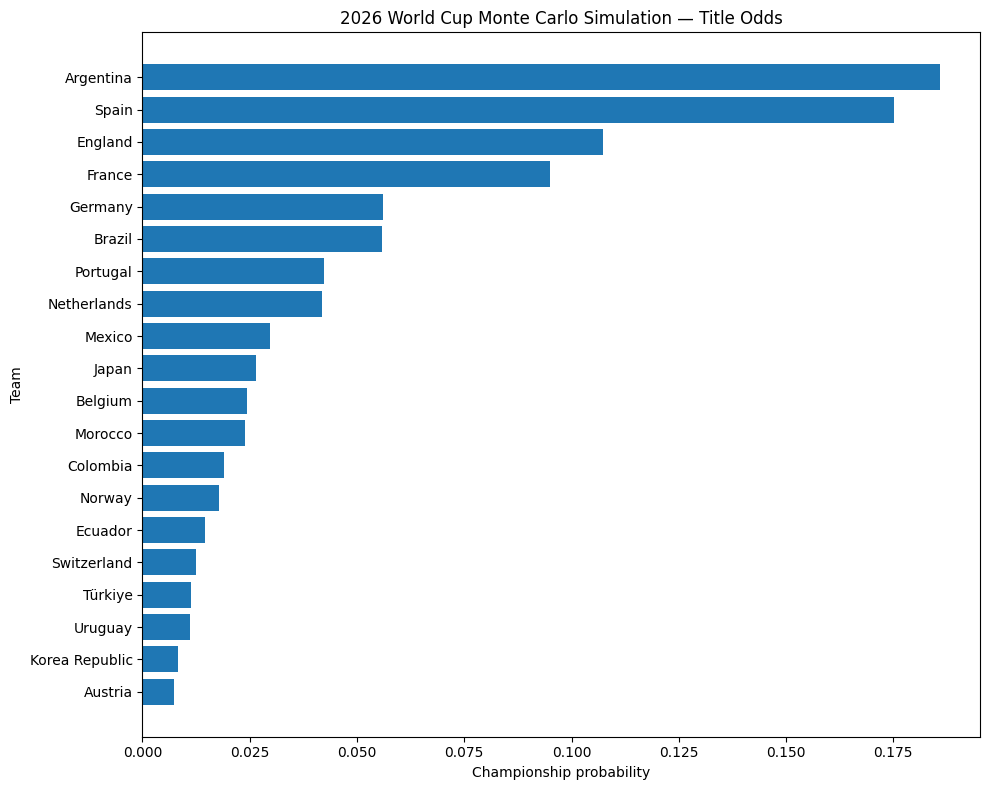

In [20]:
plot_df = results.head(20).sort_values("win_title_pct")

plt.figure(figsize=(10, 8))
plt.barh(plot_df["team"], plot_df["win_title_pct"])
plt.title("2026 World Cup Monte Carlo Simulation — Title Odds")
plt.xlabel("Championship probability")
plt.ylabel("Team")
plt.tight_layout()
plt.show()


## 9. Group advancement view

In [21]:
group_view = (
    results[display_cols]
    .sort_values(["group", "advance_from_group_pct"], ascending=[True, False])
    .reset_index(drop=True)
)

group_view


,team,group,advance_from_group_pct,reach_round_of_16_pct,reach_quarterfinal_pct,reach_semifinal_pct,reach_final_pct,win_title_pct
0,Korea Republic,Group A,0.8758,0.4254,0.1926,0.0789,0.0281,0.0084
1,Mexico,Group A,0.8430,0.5132,0.2879,0.1506,0.0716,0.0297
2,Czechia,Group A,0.6928,0.2095,0.0530,0.0117,0.0016,0.0003
3,South Africa,Group A,0.2773,0.0594,0.0093,0.0010,0.0001,0.0000
4,Switzerland,Group B,0.9672,0.4843,0.2185,0.0909,0.0333,0.0126
5,Canada,Group B,0.7883,0.3433,0.1324,0.0424,0.0121,0.0028
6,Qatar,Group B,0.4813,0.0896,0.0135,0.0014,0.0001,0.0000
7,Bosnia and Herzegovina,Group B,0.3751,0.0644,0.0103,0.0009,0.0000,0.0000
8,Morocco,Group C,0.8812,0.5224,0.2833,0.1354,0.0572,0.0239
9,Brazil,Group C,0.8359,0.5729,0.3644,0.2124,0.1143,0.0558


## 10. Save outputs

In [22]:
results_path = OUTPUT_DIR / "world_cup_2026_optimized_monte_carlo_results.csv"
group_view_path = OUTPUT_DIR / "world_cup_2026_optimized_group_advancement_results.csv"

results.to_csv(results_path, index=False)
group_view.to_csv(group_view_path, index=False)

print("Saved:")
print(results_path)
print(group_view_path)


Saved:
c:\Users\conno\OneDrive\Documents\World Cup Analytics\outputs\world_cup_2026_optimized_monte_carlo_results.csv
c:\Users\conno\OneDrive\Documents\World Cup Analytics\outputs\world_cup_2026_optimized_group_advancement_results.csv
